In [5]:
import osmnx as ox
import geopandas as gpd
import contextily as cx

In [6]:
ibge = gpd.read_file("zip://Dados/BR_Municipios_2024.zip!BR_Municipios_2024.shp")

<Axes: >

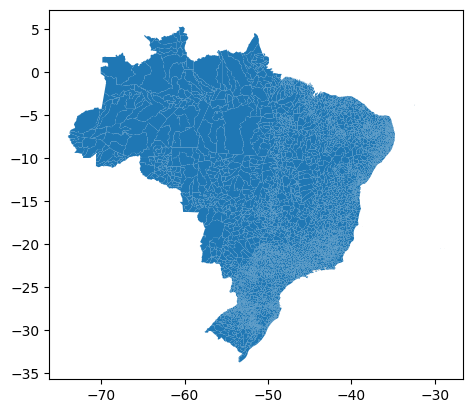

In [7]:
ibge.plot()

In [13]:
sp = ibge.loc[ibge["NM_MUN"]=="São Paulo"]
sp

,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,NM_REGIA,SIGLA_RG,CD_CONCU,NM_CONCU,AREA_KM2,geometry
309,3550308,São Paulo,350001,São Paulo,3501,São Paulo,35,São Paulo,SP,3,Sudeste,SE,3550308,São Paulo/SP,1521.202,"POLYGON ((-46.61631 -23.87255, -46.61632 -23.8..."


<Axes: >

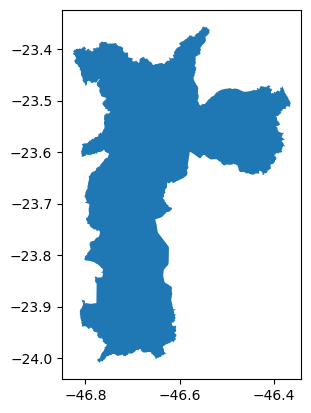

In [19]:
sp.plot()

In [34]:
tags = {
    "amenity": ['school'],#, 'community_centre', 'place_of_worship', 'clinic', 'hospital', 
                #'recycling', 'marketplace', 'kitchen', 'restaurant', 'cafe', 'fast_food', 
                #'bar', 'bus_station', 'waste_disposal', 'bicycle_parking'],
    "leisure": ['park', 'pitch', 'garden'],
    "shop": ['bakery', 'supermarket', 'convenience'],
    "landuse": ['allotments'],
    "railway": ['station'],
    "public_transport": ['station'],
    "highway": ['bus_stop', 'cycleway', 'steps', 'street_lamp'],
    "footway": ['sidewalk', 'crossing'],
    "cycleway": ['lane'],
    "water": ['river'],
    "hazard": ['flooding']
}

In [35]:
key = list(tags.keys())[0]
features = ox.features.features_from_polygon(sp.geometry.iloc[0], {key: tags[key]}) 
print("Quantidade de pontos: {}".format(len(features)))
print(features.columns)
features.head(5)

Quantidade de pontos: 1543
Index(['geometry', 'amenity', 'name', 'name:en', 'wheelchair', 'wikidata',
       'wikipedia', 'addr:housenumber', 'addr:street', 'education',
       ...
       'payment:maestro', 'payment:mastercard', 'payment:pikepass',
       'payment:uta', 'payment:visa', 'payment:visa_debit',
       'payment:visa_electron', 'tourism', 'area', 'surface'],
      dtype='str', length=154)


geometry amenity  \
element id                                               
node    525522286  POINT (-46.70408 -23.63375)  school   
        638425993  POINT (-46.59965 -23.54121)  school   
        696175114  POINT (-46.69814 -23.63585)  school   
        745728710  POINT (-46.63487 -23.56367)  school   
        922094743  POINT (-46.62986 -23.59226)  school   

                                            name                     name:en  \
element id                                                                     
node    525522286                            NaN                         NaN   
        638425993  Colégio Presbiteriano do Brás                         NaN   
        696175114                    Coreo Dança                         NaN   
        745728710             Anglo Vestibulares                         NaN   
        922094743                  Lycee Pasteur  Lycée Pasteur de São Paulo   

                  wheelchair  wikidata         wikipedia addr:housenumber  \
element id                                                                  
node    525522286        NaN       NaN               NaN              NaN   
        638425993        NaN       NaN               NaN              NaN   
        696175114        NaN       NaN               NaN              NaN   
        745728710        NaN       NaN               NaN              NaN   
        922094743        yes  Q3268878  pt:Liceu Pasteur              NaN   

                  addr:street education  ... payment:maestro  \
element id                               ...                   
node    525522286         NaN       NaN  ...             NaN   
        638425993         NaN       NaN  ...             NaN   
        696175114         NaN       NaN  ...             NaN   
        745728710         NaN       NaN  ...             NaN   
        922094743         NaN       NaN  ...             NaN   

                  payment:mastercard payment:pikepass payment:uta  \
element id                                                          
node    525522286                NaN              NaN         NaN   
        638425993                NaN              NaN         NaN   
        696175114                NaN              NaN         NaN   
        745728710                NaN              NaN         NaN   
        922094743                NaN              NaN         NaN   

                  payment:visa payment:visa_debit payment:visa_electron  \
element id                                                                
node    525522286          NaN                NaN                   NaN   
        638425993          NaN                NaN                   NaN   
        696175114          NaN                NaN                   NaN   
        745728710          NaN                NaN                   NaN   
        922094743          NaN                NaN                   NaN   

                  tourism area surface  
element id                              
node    525522286     NaN  NaN     NaN  
        638425993     NaN  NaN     NaN  
        696175114     NaN  NaN     NaN  
        745728710     NaN  NaN     NaN  
        922094743     NaN  NaN     NaN  

[5 rows x 154 columns]

In [40]:
features.reset_index().element.value_counts()

element
way         1194
node         264
relation      85
Name: count, dtype: int64

In [51]:
# Converter polygons em centroides (pontos)
features_points = features.copy()
features_points.geometry = features_points.geometry.centroid
print("Geometrias convertidas para centroides")
print(f"Tipos de geometria: {features.geometry.geom_type.unique()}")

Geometrias convertidas para centroides
Tipos de geometria: <StringArray>
['Point', 'Polygon', 'MultiPolygon']
Length: 3, dtype: str


C:\Users\9837292\AppData\Local\Temp\ipykernel_22824\3152649697.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  features_points.geometry = features_points.geometry.centroid


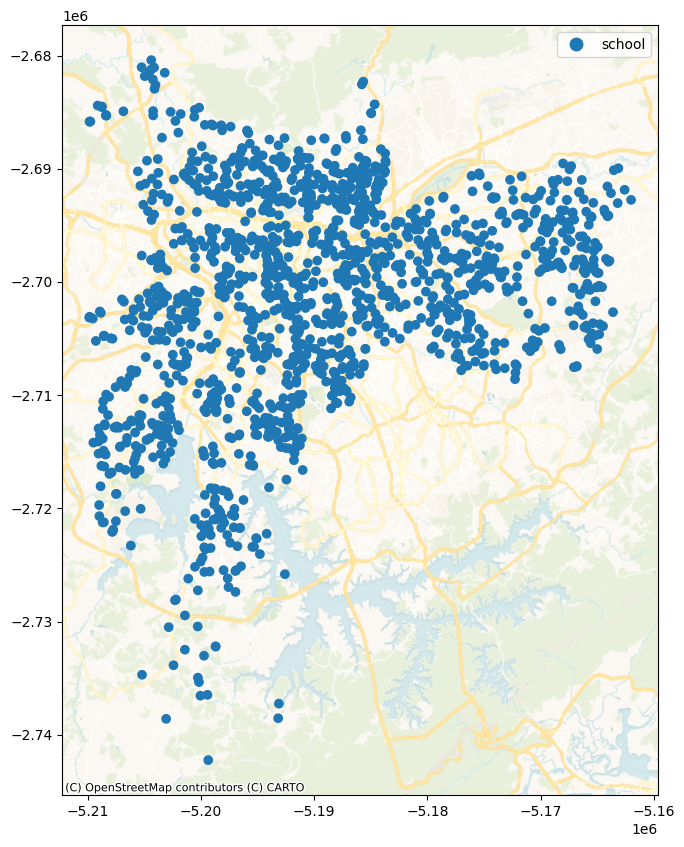

In [52]:
ax = features_points.to_crs(epsg=3857).plot(
    column=key, 
    categorical=True, 
    legend=True,
    figsize=(10, 10),
    cmap='tab20',
    missing_kwds={'color': 'lightgrey'}
)
cx.add_basemap(ax, source=cx.providers.CartoDB.VoyagerNoLabels)